In [2]:
%load_ext autoreload
%autoreload 2

# Sequence-level memorization overlap

Do different attention variants memorize the *same* Gutenberg excerpts within a repetition bucket, or different ones? Every model's inference reads the same, unshuffled `rep_R_token.jsonl` (`evaluation/megatron_inference_sparse.py`), so sample order is shared across models -- comparing per-sequence Rouge-L needs no book-id join, just matching sample index. See `results/docs/memorization_measurement.md` for the underlying pipeline and `plotting/memorization_overlap.py` for the loading/plotting code.

In [3]:
import os
import sys

PDM_DIR = os.environ.get('PDM_DIR', '../../../../PDM')
sys.path.append(f'{PDM_DIR}/src')
import verbatim_eval.controlled_expr as _ce
import verbatim_eval.rouge_ttr as _rt
import verbatim_eval.utils as _ut
sys.modules['controlled_expr'] = _ce  # needed for pickle deserialization
sys.modules['rouge_ttr'] = _rt
sys.modules['utils'] = _ut

sys.path.insert(0, '../../..')

from attn_bench.plotting import model_registry
from attn_bench.plotting.memorization_overlap import load_sequence_matrix, plot_sequence_overlap_heatmap

# Every model in model_registry.MODELS, grouped/ordered like MODEL_COLORS -- comment out
# individual lines (or a whole family) to change what's plotted below.
MODELS = [
    # full-attention family
    "full-scf8",
    "full-xdl-scf8",
    "full-goldfish-scf8",
    "full-80B-scf8",
    # sink family (softmax-denominator variants)
    "gated-scf8",
    "learn-sink-scf8",
    "off-by-one-scf8",
    # GDN family
    "gdn",
    "gdn-xdl",
    "gdn-xdl-xsl-0.5",
    "gdn-xdl-xsl",
    "gdn-goldfish",
    # long vs short training-doc-length pair
    "full-long-docs-scf8",
    "full-short-docs-scf8",
]

# (offset, prefix, suffix) point -- see results/docs/memorization_measurement.md's
# offset/prefix/suffix vocabulary. Main comparison across the study is offset=0,
# prefix=500, suffix=500; edit PREFIX/SUFFIX to look at a different point on the grid.
PREFIX = 500
SUFFIX = 500

## rep=256 (heaviest repetition)

Most training exposure -- the overlap pattern should be clearest here. Columns are the bucket's 660 sequences, sorted by mean Rouge-L across the selected models (consensus first).

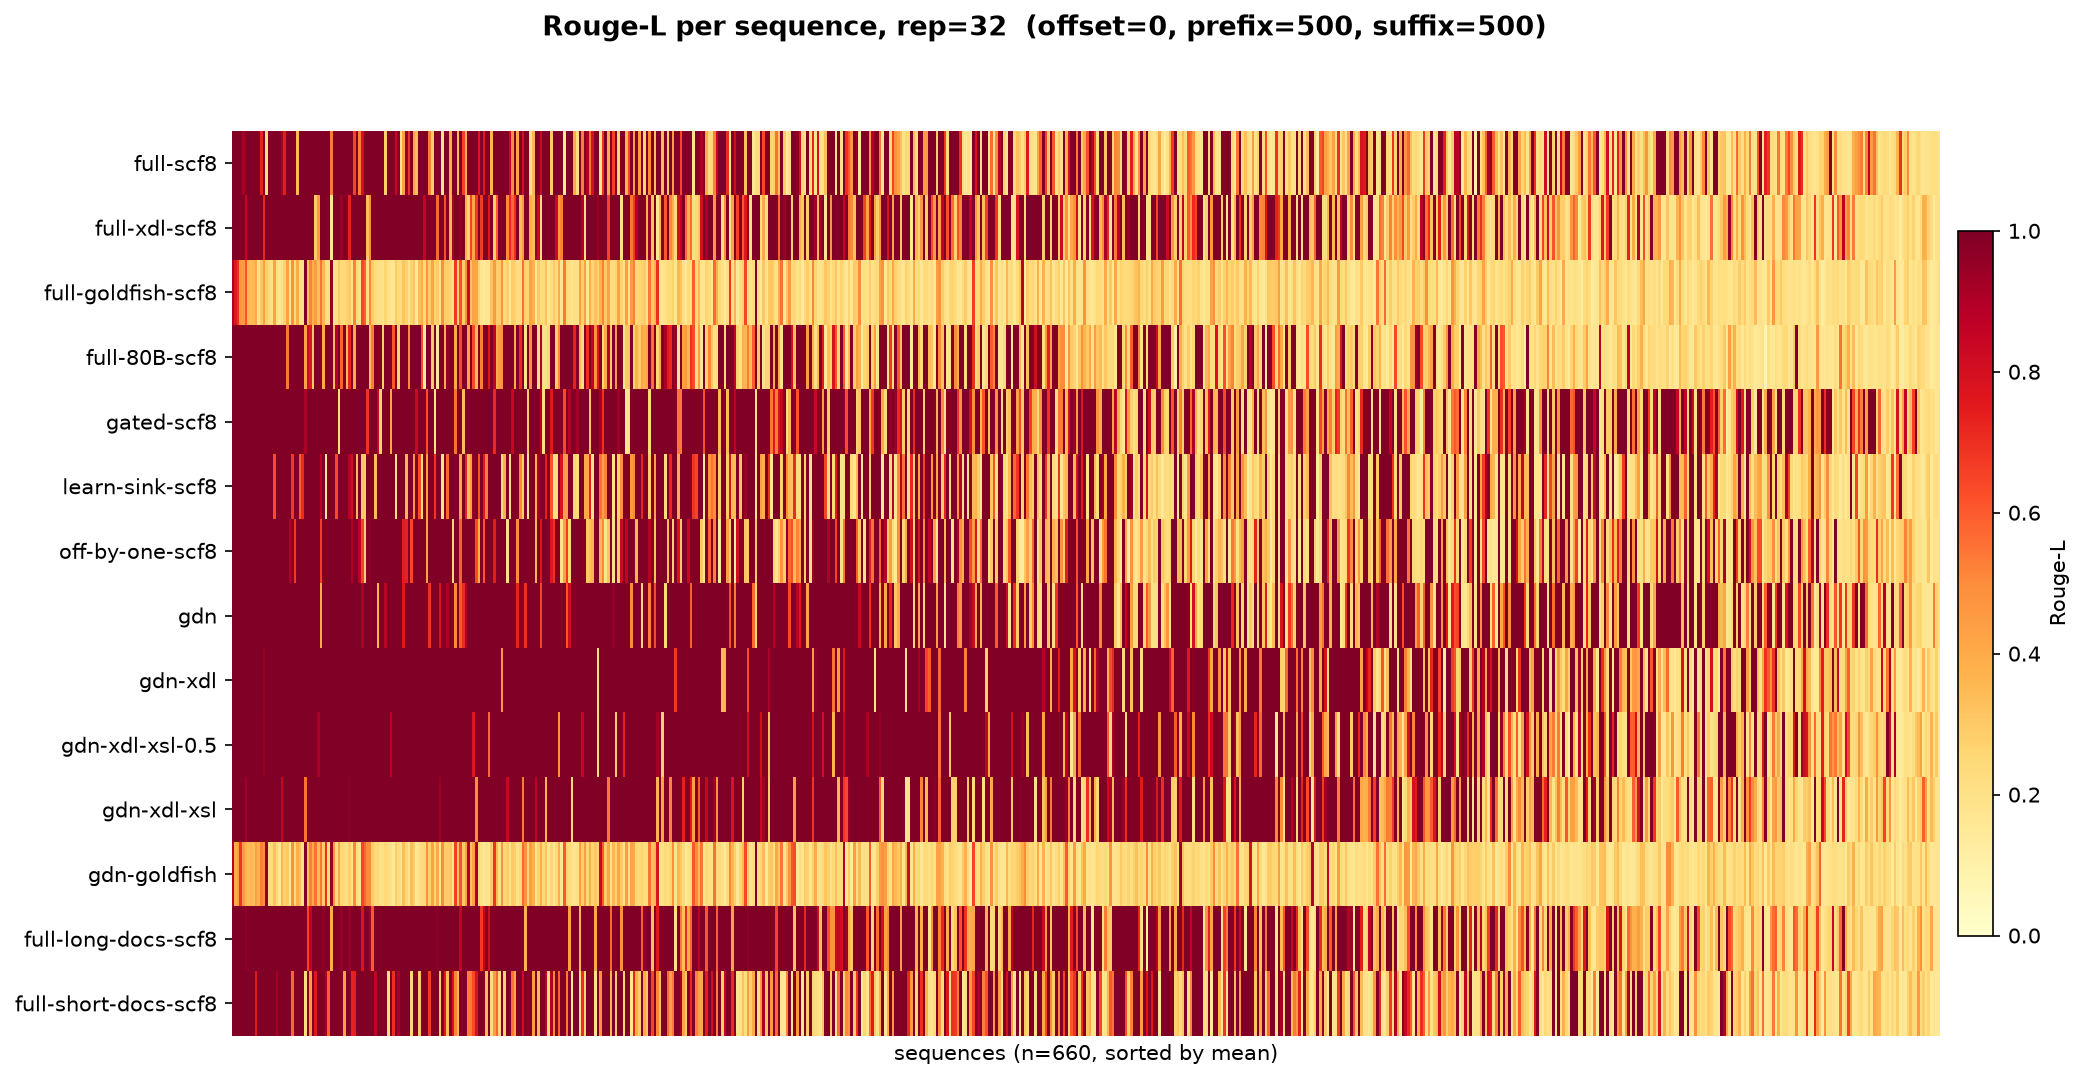

In [6]:
mat, labels = plot_sequence_overlap_heatmap(rep=32, models=MODELS, prefix=PREFIX, suffix=SUFFIX)

## rep=32 (moderate repetition)

Same models, lower repetition count -- compare against rep=256 above to see whether the *pattern* of agreement (not just the amount of memorization) shifts with repetition count.

In [ ]:
mat, labels = plot_sequence_overlap_heatmap(rep=32, models=MODELS, prefix=PREFIX, suffix=SUFFIX)

## Consensus check

Quick numeric readout underneath the picture above: with a Rouge-L threshold for "memorized," how many sequences are memorized by *all* selected models vs by only one? A lightweight preview of what a full set-intersection (UpSet-style) breakdown would show, without building that view yet.

In [5]:
import numpy as np

REP = 256
THRESHOLD = 0.5

matrix = load_sequence_matrix(REP, models=MODELS, prefix=PREFIX, suffix=SUFFIX)
consensus_labels = list(matrix.keys())
consensus_mat = np.stack([matrix[m] for m in consensus_labels])
memorized = consensus_mat > THRESHOLD  # [n_models, n_sequences] bool

agreement_counts = memorized.sum(axis=0)  # how many models memorized each sequence
print(f"rep={REP}, Rouge-L > {THRESHOLD}, models={consensus_labels}\n")
for n in range(len(consensus_labels) + 1):
    count = int((agreement_counts == n).sum())
    print(f"  memorized by exactly {n}/{len(consensus_labels)} models: {count}")

rep=256, Rouge-L > 0.5, models=['full-scf8', 'full-xdl-scf8', 'full-goldfish-scf8', 'full-80B-scf8', 'gated-scf8', 'learn-sink-scf8', 'off-by-one-scf8', 'gdn', 'gdn-xdl', 'gdn-xdl-xsl-0.5', 'gdn-xdl-xsl', 'gdn-goldfish', 'full-long-docs-scf8', 'full-short-docs-scf8']

  memorized by exactly 0/14 models: 0
  memorized by exactly 1/14 models: 0
  memorized by exactly 2/14 models: 0
  memorized by exactly 3/14 models: 0
  memorized by exactly 4/14 models: 0
  memorized by exactly 5/14 models: 0
  memorized by exactly 6/14 models: 0
  memorized by exactly 7/14 models: 0
  memorized by exactly 8/14 models: 0
  memorized by exactly 9/14 models: 0
  memorized by exactly 10/14 models: 0
  memorized by exactly 11/14 models: 10
  memorized by exactly 12/14 models: 588
  memorized by exactly 13/14 models: 29
  memorized by exactly 14/14 models: 33
